In [3]:
# !uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

In [1]:


from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain


from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")



/home/user/users/shubhom/tribev2/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/user/users/shubhom/tribev2/.conda/lib/python3.12/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-07 22:18:13 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/home/user/users/shubhom/tribev2/.conda/lib/python3.12/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure 

In [2]:
import torch
from tribev2 import TribeModel

torch.cuda.set_device(0)

model = TribeModel.from_pretrained("facebook/tribev2", cache_folder="./cache")

df = model.get_events_dataframe(video_path="sample_video/DEVO2/311-Baking Cookies Timelapse-ED.mp4")
preds, segments = model.predict(events=df)
print(preds.shape)  # (n_timesteps, n_vertices)

2026-04-07 22:18:18 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /home/user/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 3093.14it/s]
/home/user/users/shubhom/tribev2/.conda/lib/python3.12/site-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 1281.09it/s]
No transcripts found, skipping
2026-04-07 22:18:20 - INFO - neuralset.events.transforms.text:56 - No

(20, 20484)


Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.33it/s]


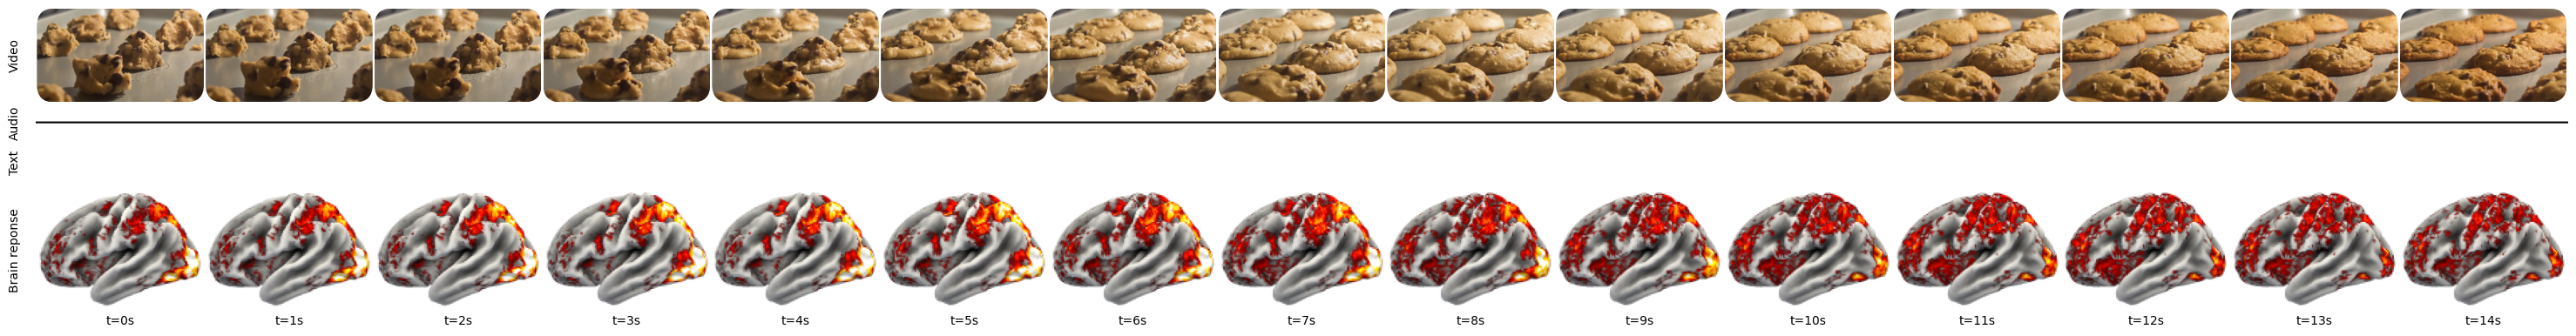

In [12]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [13]:
df2 = model.get_events_dataframe(video_path="sample_video/DEVO2/553-Woman Eating a Pizza While Using Cellphone-ED.mp4")
preds2, segments2 = model.predict(events=df2)
print(preds2.shape)  # (n_timesteps, n_vertices)

Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 3799.19it/s]
/home/user/users/shubhom/tribev2/.conda/lib/python3.12/site-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 1583.95it/s]
No transcripts found, skipping
2026-04-07 14:19:23 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
2026-04-07 14:19:23 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[14:19:23 WARNING] Removing extractor text as there are no corresponding events
[14:19:23 INFO] Preparing extractor: audio
[14:19:23 INFO] Preparing extractor: video
Loading weights: 100%|██████████| 843/843 [00:00<00:00, 12220.94it/s]
2026-04-07 14:19:24 - DEBUG - neuralset.extractors.video:

(11, 20484)


Plotting...: 100%|██████████| 11/11 [00:02<00:00,  4.91it/s]


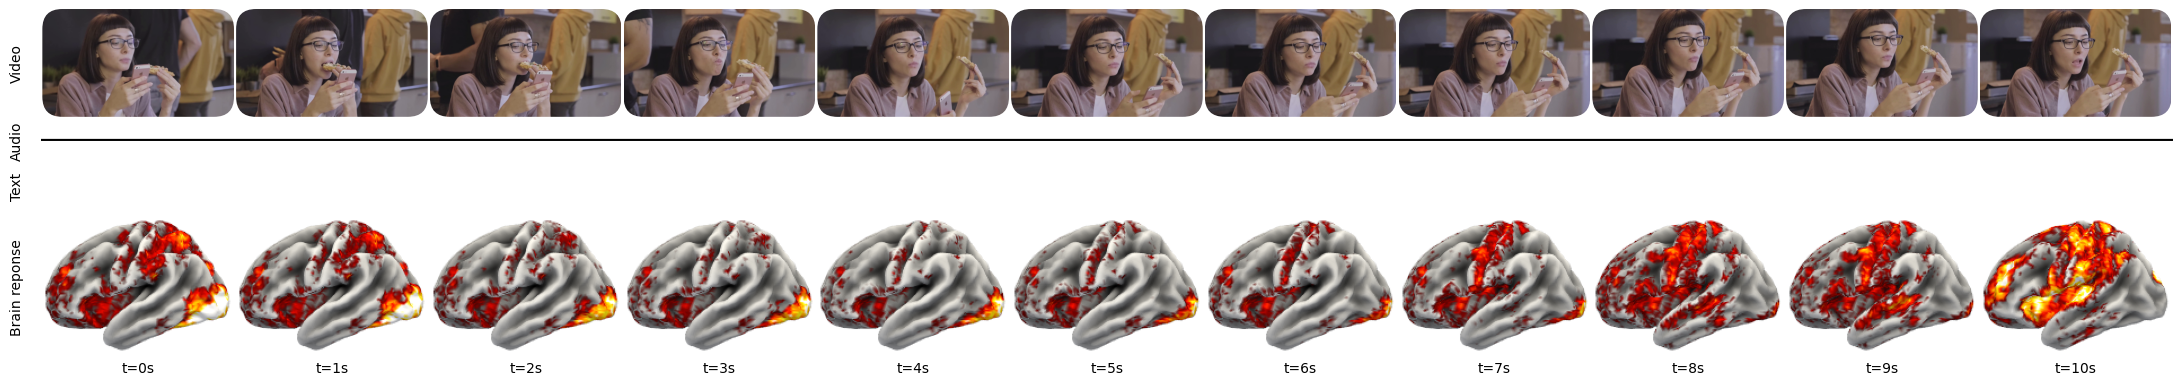

In [14]:
fig = plotter.plot_timesteps(preds2[:n_timesteps], segments=segments2[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [ ]:
!nvidia-smi

Tue Apr  7 14:18:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:C1:00.0  On |                  Off |
| 41%   65C    P0            101W /  300W |   36227MiB /  49140MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----